# Notebook 02 — Preprocessing & Augmentation Pipeline
## Edge AI Acoustic Border Intrusion Detection

---

### Context from EDA (Notebook 01)
| Issue Identified | Action in This Notebook |
|-----------------|------------------------|
| 40 footstep files at wrong SR | Force resample all → 16 kHz |
| 15 clipped files (balastic+noise) | Peak normalisation |
| 1 silent noise file | Flag and remove |
| Footstep kurtosis = 345 (sparse transients) | Energy-VAD gating before feature extraction |
| Class imbalance 4.68:2.60:1.00 | Augmentation → target 320 footstep samples |
| C0/C1 dominate MFCC dynamics | Extract 8 MFCCs + Δ + ΔΔ = 24-dim vector |
| Variable durations (3–5s) | Hard trim/pad to exactly 3.0s |

### Pipeline Stages

In [1]:
import os, shutil, warnings, random
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
from collections import defaultdict

import librosa
import librosa.display
import soundfile as sf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

# ── Research Plot Style ──────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":         12,
    "axes.labelsize":    13,
    "axes.titlesize":    13,
    "axes.linewidth":    1.2,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "xtick.major.size":  6,
    "ytick.major.size":  6,
    "xtick.minor.size":  3,
    "ytick.minor.size":  3,
    "legend.fontsize":   11,
    "legend.frameon":    True,
    "legend.edgecolor":  "0.4",
    "grid.linestyle":    ":",
    "grid.linewidth":    0.7,
    "grid.alpha":        0.85,
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
})

def paper_axes(ax):
    ax.minorticks_on()
    ax.grid(True, which="major", linestyle=":", linewidth=0.8)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.6)
    for sp in ax.spines.values():
        sp.set_linewidth(1.2)
    ax.tick_params(which="both", direction="in", top=True, right=True)

CLASS_COLORS = {
    "footsteps": "#2166ac",
    "noise":     "#d6604d",
    "balastic":  "#4dac26",
}

# ── Pipeline Config ──────────────────────────────────────────────────────────
DATASET_PATH    = Path("/kaggle/input/datasets/katakuricharlotte/borderintrusiondetection-data/dataset")
OUTPUT_PATH     = Path("/kaggle/working/processed")
FIGURES_PATH    = Path("/kaggle/working/figures")
PROCESSED_AUDIO = OUTPUT_PATH / "audio_clean"

SR              = 16000
CLIP_DURATION   = 3.0
CLIP_SAMPLES    = int(SR * CLIP_DURATION)

# MFCC config (informed by EDA: C0-C7 sufficient)
N_MFCC          = 8
N_FFT           = 512
HOP_LENGTH      = 256
N_MELS          = 40
FEATURE_DIM     = N_MFCC * 3   # mfcc + delta + delta-delta = 24

# Augmentation targets
AUG_TARGET      = {"footsteps": 320, "noise": 280, "balastic": 374}
RMS_SILENCE_THR = 0.001
RMS_VAD_THR     = 0.002

for p in [OUTPUT_PATH, FIGURES_PATH, PROCESSED_AUDIO]:
    p.mkdir(parents=True, exist_ok=True)

print("Pipeline configuration:")
print(f"  SR={SR} Hz | Clip={CLIP_DURATION}s | N_MFCC={N_MFCC} | Feature dim={FEATURE_DIM}")
print(f"  Augmentation targets: {AUG_TARGET}")

Pipeline configuration:
  SR=16000 Hz | Clip=3.0s | N_MFCC=8 | Feature dim=24
  Augmentation targets: {'footsteps': 320, 'noise': 280, 'balastic': 374}


## Stage 1 — Quality Filter

Load all raw files and apply three quality gates:
1. **Silent files** — RMS < 0.001 → remove from pipeline
2. **SR mismatch** — flag (will be fixed in Stage 2, not removed)
3. **Clipped files** — flag (will be normalised in Stage 2, not removed)

Output: `quality_df` with per-file flags and a clean `valid_df` for processing.

In [2]:
records = []
for cls_dir in sorted(DATASET_PATH.iterdir()):
    if not cls_dir.is_dir():
        continue
    label = cls_dir.name
    for wav_path in sorted(cls_dir.rglob("*.wav")):
        try:
            info = sf.info(str(wav_path))
            records.append({
                "path":       str(wav_path),
                "filename":   wav_path.name,
                "label":      label,
                "native_sr":  info.samplerate,
                "duration_s": round(info.duration, 4),
                "channels":   info.channels,
            })
        except Exception as e:
            print(f"  ⚠ Unreadable: {wav_path.name} — {e}")

raw_df = pd.DataFrame(records)
print(f"Total raw files: {len(raw_df)}")
print(raw_df["label"].value_counts().to_string())

Total raw files: 662
label
balastic     374
noise        208
footsteps     80


In [3]:
quality_flags = []

print("Running quality gate...")
for _, row in tqdm(raw_df.iterrows(), total=len(raw_df)):
    try:
        y, sr = librosa.load(row["path"], sr=None, mono=True)
        rms_val    = float(np.sqrt(np.mean(y ** 2)))
        clip_ratio = float(np.mean(np.abs(y) > 0.99))
        quality_flags.append({
            "path":        row["path"],
            "filename":    row["filename"],
            "label":       row["label"],
            "native_sr":   sr,
            "rms":         round(rms_val, 6),
            "clip_ratio":  round(clip_ratio, 5),
            "is_silent":   rms_val < RMS_SILENCE_THR,
            "is_clipped":  clip_ratio > 0.01,
            "sr_mismatch": sr != SR,
        })
    except Exception as e:
        quality_flags.append({
            "path": row["path"], "filename": row["filename"],
            "label": row["label"], "native_sr": None,
            "rms": 0, "clip_ratio": 0,
            "is_silent": True, "is_clipped": False, "sr_mismatch": True,
        })

qual_df = pd.DataFrame(quality_flags)

print("\n── Quality Gate Summary ─────────────────────────────────")
print(f"  Total files       : {len(qual_df)}")
print(f"  Silent (REMOVED)  : {qual_df['is_silent'].sum()}")
print(f"  SR mismatch       : {qual_df['sr_mismatch'].sum()}  → will resample")
print(f"  Clipped           : {qual_df['is_clipped'].sum()}   → will normalise")
print("─────────────────────────────────────────────────────────")

# Remove silent files
valid_df = qual_df[~qual_df["is_silent"]].reset_index(drop=True)
removed_df = qual_df[qual_df["is_silent"]]

print(f"\nFiles removed (silent): {len(removed_df)}")
for _, r in removed_df.iterrows():
    print(f"  ✗ [{r['label']}] {r['filename']}  (RMS={r['rms']:.6f})")

print(f"\nFiles proceeding to Stage 2: {len(valid_df)}")
print(valid_df["label"].value_counts().to_string())

Running quality gate...


  0%|          | 0/662 [00:00<?, ?it/s]


── Quality Gate Summary ─────────────────────────────────
  Total files       : 662
  Silent (REMOVED)  : 1
  SR mismatch       : 40  → will resample
  Clipped           : 15   → will normalise
─────────────────────────────────────────────────────────

Files removed (silent): 1
  ✗ [noise] crickets_2-110613-A-13.wav  (RMS=0.000155)

Files proceeding to Stage 2: 661
label
balastic     374
noise        207
footsteps     80


## Stage 2 — Canonical Preprocessing

Every valid file is processed through a deterministic pipeline:



The processed audio files serve as the **reproducible clean base** for all feature extraction and augmentation.

In [4]:
def preprocess_audio(src_path: str, label: str, is_clipped: bool) -> np.ndarray:
    """Load, resample, normalise, trim/pad → return float32 array of CLIP_SAMPLES."""
    y, sr = librosa.load(src_path, sr=SR, mono=True)

    # Peak normalise (always — safe for clipped AND clean)
    peak = np.max(np.abs(y))
    if peak > 0:
        y = y / peak * 0.95   # leave 5% headroom

    # Trim silence at edges (aggressive only for footsteps — sparse transients)
    if label == "footsteps":
        y, _ = librosa.effects.trim(y, top_db=40)

    # Hard trim or zero-pad to CLIP_SAMPLES
    if len(y) >= CLIP_SAMPLES:
        # Centre crop for footsteps (keep burst), front crop for others
        if label == "footsteps":
            start = max(0, (len(y) - CLIP_SAMPLES) // 2)
        else:
            start = 0
        y = y[start: start + CLIP_SAMPLES]
    else:
        pad_len = CLIP_SAMPLES - len(y)
        y = np.pad(y, (0, pad_len), mode="constant")

    return y.astype(np.float32)

In [5]:
processed_records = []
fail_count = 0

print("Preprocessing all valid files...")
for _, row in tqdm(valid_df.iterrows(), total=len(valid_df)):
    try:
        y_clean = preprocess_audio(row["path"], row["label"], row["is_clipped"])

        # Save processed wav
        label_dir = PROCESSED_AUDIO / row["label"]
        label_dir.mkdir(parents=True, exist_ok=True)
        out_path = label_dir / row["filename"]
        sf.write(str(out_path), y_clean, SR, subtype="PCM_16")

        processed_records.append({
            "path":       str(out_path),
            "filename":   row["filename"],
            "label":      row["label"],
            "rms_before": row["rms"],
            "rms_after":  float(np.sqrt(np.mean(y_clean ** 2))),
            "clipped":    row["is_clipped"],
            "sr_fixed":   row["sr_mismatch"],
            "split":      "raw",   # will be assigned in Stage 5
        })
    except Exception as e:
        fail_count += 1
        print(f"  ✗ Failed: {row['filename']} — {e}")

proc_df = pd.DataFrame(processed_records)
print(f"\n Processed: {len(proc_df)} files  |  Failed: {fail_count}")
print(proc_df["label"].value_counts().to_string())
print(f"\nAll processed audio saved to: {PROCESSED_AUDIO}")

Preprocessing all valid files...


  0%|          | 0/661 [00:00<?, ?it/s]


 Processed: 661 files  |  Failed: 0
label
balastic     374
noise        207
footsteps     80

All processed audio saved to: /kaggle/working/processed/audio_clean


KeyError: 'duration_s'

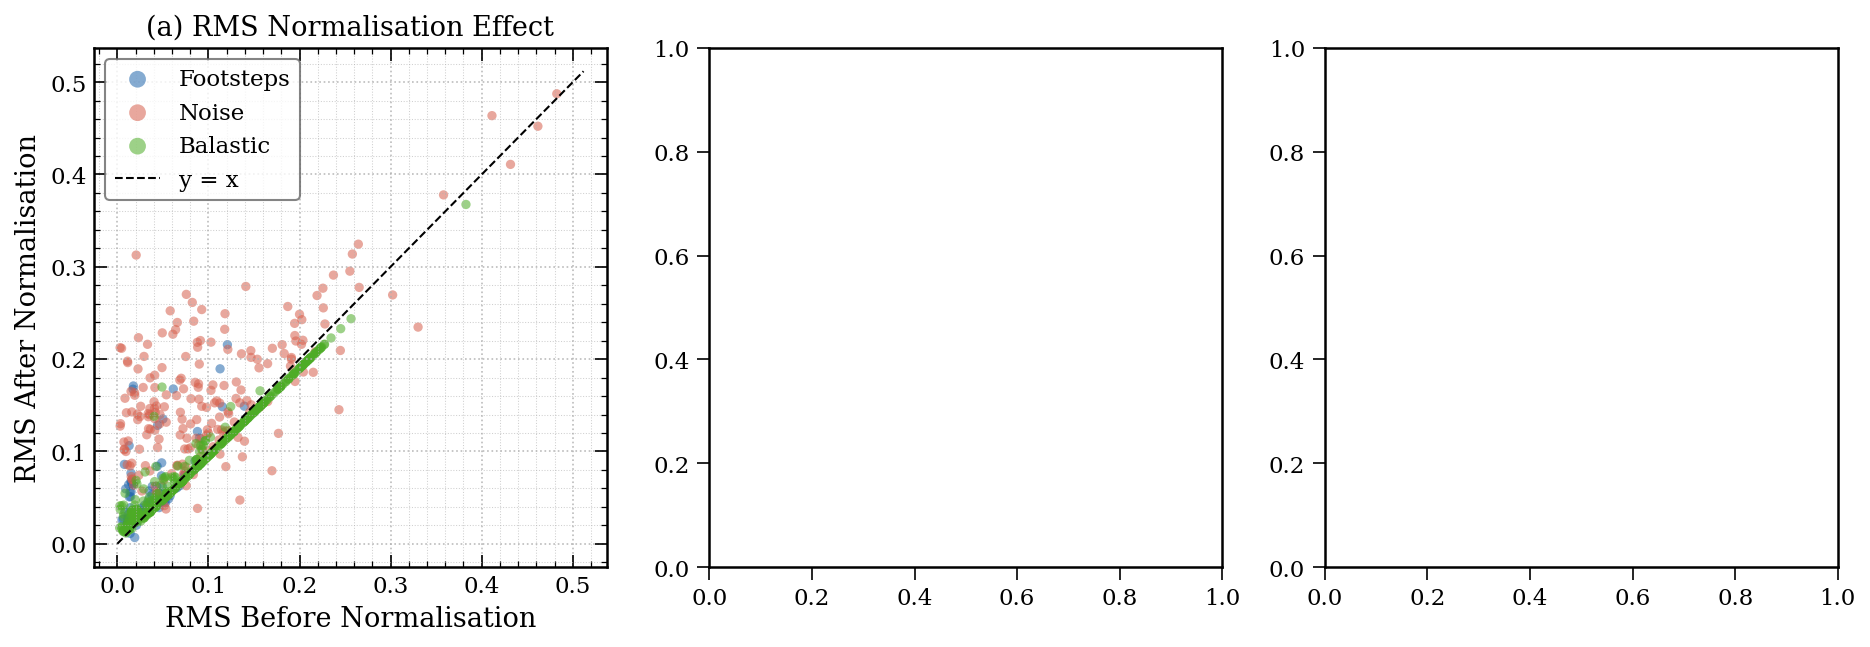

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── A: RMS before vs after normalisation ────────────────────────────────────
ax = axes[0]
for label, color in CLASS_COLORS.items():
    sub = proc_df[proc_df["label"] == label]
    if sub.empty: continue
    ax.scatter(sub["rms_before"], sub["rms_after"], color=color, alpha=0.55,
               s=20, edgecolors="none", label=label.capitalize())
lim_max = max(proc_df["rms_before"].max(), proc_df["rms_after"].max()) * 1.05
ax.plot([0, lim_max], [0, lim_max], "k--", linewidth=1.0, label="y = x")
ax.set_xlabel("RMS Before Normalisation")
ax.set_ylabel("RMS After Normalisation")
ax.set_title("(a) RMS Normalisation Effect")
ax.legend(markerscale=1.8)
paper_axes(ax)

# ── B: Duration before vs after (seconds) ───────────────────────────────────
ax = axes[1]
raw_dur_by_class = {r["label"]: [] for r in processed_records}
for r in processed_records:
    raw_dur_by_class[r["label"]].append(
        valid_df[valid_df["filename"] == r["filename"]]["duration_s"].values[0]
        if r["filename"] in valid_df["filename"].values else CLIP_DURATION
    )

classes = [c for c in CLASS_COLORS if c in raw_dur_by_class]
data_before = [raw_dur_by_class[c] for c in classes]

bp = ax.boxplot(data_before, patch_artist=True, notch=False,
                medianprops=dict(color="black", linewidth=2),
                positions=np.arange(len(classes)) * 2 - 0.35, widths=0.6)
for patch, cls in zip(bp["boxes"], classes):
    patch.set_facecolor(CLASS_COLORS[cls])
    patch.set_alpha(0.5)

ax.axhline(CLIP_DURATION, color="red", linewidth=1.5, linestyle="--",
           label=f"Target = {CLIP_DURATION}s")
ax.set_xticks(np.arange(len(classes)) * 2 - 0.35)
ax.set_xticklabels([c.capitalize() for c in classes])
ax.set_ylabel("Duration (seconds)")
ax.set_title("(b) Pre-processing Duration Distribution")
ax.legend()
paper_axes(ax)

# ── C: SR fix summary ────────────────────────────────────────────────────────
ax = axes[2]
sr_fixed   = proc_df[proc_df["sr_fixed"] == True]["label"].value_counts()
sr_ok      = proc_df[proc_df["sr_fixed"] == False]["label"].value_counts()
clip_fixed = proc_df[proc_df["clipped"] == True]["label"].value_counts()
all_labels = list(CLASS_COLORS.keys())

x = np.arange(len(all_labels))
w = 0.28
ax.bar(x - w,  [sr_fixed.get(l, 0)   for l in all_labels], width=w,
       label="SR Resampled",   color="#4393c3", edgecolor="black", linewidth=0.7)
ax.bar(x,      [clip_fixed.get(l, 0) for l in all_labels], width=w,
       label="Peak Normalised", color="#d6604d", edgecolor="black", linewidth=0.7)
ax.bar(x + w,  [sr_ok.get(l, 0)      for l in all_labels], width=w,
       label="Clean (no fix)",  color="#4dac26", edgecolor="black", linewidth=0.7)

ax.set_xticks(x)
ax.set_xticklabels([l.capitalize() for l in all_labels])
ax.set_ylabel("File Count")
ax.set_title("(c) Preprocessing Corrections Applied")
ax.legend()
paper_axes(ax)

plt.suptitle("Stage 2 — Canonical Preprocessing Validation", fontsize=13,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(str(FIGURES_PATH / "fig_preprocessing_validation.pdf"))
plt.show()
print("Saved → fig_preprocessing_validation.pdf")

## Stage 3 — Data Augmentation

### Strategy
The footstep class (80 samples) must reach **320 samples** (4× augmentation).
Noise and balastic receive **mild augmentation** to prevent the model from memorising
specific file characteristics.

### Augmentation Techniques
| Technique | Parameters | Physical Justification |
|-----------|------------|----------------------|
| **Time Stretch** | rate ∈ [0.80, 1.25] | Variation in walking pace |
| **Pitch Shift** | n_steps ∈ [−3, +3] semitones | Different footwear / surface hardness |
| **Additive Gaussian Noise** | SNR ∈ [10, 25] dB | Environmental background noise |
| **Time Shift** | shift ∈ [−0.5s, +0.5s] | Sensor placement variation |
| **Gain Variation** | gain ∈ [0.6, 1.0] | Distance from sensor variation |
| **Mixup** | α = 0.3 (same-class) | Regularisation — blends two same-class samples |

### Class Targets After Augmentation
| Class | Original | Target | Augmentation Factor |
|-------|----------|--------|---------------------|
| Footsteps | 80 | 320 | ×4.0 |
| Noise | 207 | 280 | ×1.35 |
| Balastic | 374 | 374 | ×1.0 (no augmentation) |

In [ ]:
def aug_time_stretch(y: np.ndarray, sr: int) -> np.ndarray:
    rate = np.random.uniform(0.80, 1.25)
    y_aug = librosa.effects.time_stretch(y, rate=rate)
    return _fix_length(y_aug)

def aug_pitch_shift(y: np.ndarray, sr: int) -> np.ndarray:
    steps = np.random.uniform(-3, 3)
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=steps)

def aug_add_noise(y: np.ndarray, sr: int) -> np.ndarray:
    snr_db  = np.random.uniform(10, 25)
    sig_pow = np.mean(y ** 2) + 1e-9
    noise_pow = sig_pow / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_pow), len(y)).astype(np.float32)
    return np.clip(y + noise, -1.0, 1.0)

def aug_time_shift(y: np.ndarray, sr: int) -> np.ndarray:
    max_shift = int(0.5 * sr)
    shift = np.random.randint(-max_shift, max_shift)
    return np.roll(y, shift).astype(np.float32)

def aug_gain(y: np.ndarray, sr: int) -> np.ndarray:
    gain = np.random.uniform(0.6, 1.0)
    return (y * gain).astype(np.float32)

def aug_mixup(y1: np.ndarray, y2: np.ndarray, alpha: float = 0.3) -> np.ndarray:
    lam = np.random.beta(alpha, alpha)
    lam = max(0.3, min(0.7, lam))   # keep both contributions meaningful
    return (lam * y1 + (1 - lam) * y2).astype(np.float32)

def _fix_length(y: np.ndarray) -> np.ndarray:
    if len(y) >= CLIP_SAMPLES:
        start = (len(y) - CLIP_SAMPLES) // 2
        return y[start: start + CLIP_SAMPLES]
    return np.pad(y, (0, CLIP_SAMPLES - len(y)), mode="constant")

AUG_POOL = [aug_time_stretch, aug_pitch_shift, aug_add_noise,
            aug_time_shift, aug_gain]

def augment_sample(y: np.ndarray, sr: int,
                   pool_audio: list = None, n_transforms: int = 2) -> np.ndarray:
    """Apply n_transforms randomly chosen augmentations. Optionally apply mixup."""
    chosen = random.sample(AUG_POOL, min(n_transforms, len(AUG_POOL)))
    y_aug = y.copy()
    for fn in chosen:
        y_aug = fn(y_aug, sr)

    if pool_audio and random.random() < 0.3:  # 30% chance of mixup
        y2 = random.choice(pool_audio)
        y_aug = aug_mixup(y_aug, y2)

    # Re-normalise after augmentation
    peak = np.max(np.abs(y_aug))
    if peak > 0:
        y_aug = y_aug / peak * 0.95
    return _fix_length(y_aug)

print("Augmentation functions defined.")
print(f"Techniques available: {[f.__name__ for f in AUG_POOL]}")

In [ ]:
audio_bank = defaultdict(list)   # label → list of np.ndarray
path_bank  = defaultdict(list)   # label → list of file paths

print("Loading processed audio into memory...")
for _, row in tqdm(proc_df.iterrows(), total=len(proc_df)):
    try:
        y, _ = librosa.load(row["path"], sr=SR, mono=True)
        y = _fix_length(y)
        audio_bank[row["label"]].append(y)
        path_bank[row["label"]].append(row["path"])
    except Exception as e:
        print(f"  ✗ {row['filename']}: {e}")

print("\nAudio loaded:")
for lbl, arr in audio_bank.items():
    print(f"  {lbl:<12}: {len(arr)} files  |  "
          f"~{len(arr)*CLIP_DURATION/60:.1f} min total")

In [ ]:
augmented_records = []   # will hold ALL samples (original + augmented)

for label, target_count in AUG_TARGET.items():
    originals = audio_bank[label]
    n_orig    = len(originals)

    if n_orig == 0:
        print(f"  ⚠ No audio loaded for {label}, skipping.")
        continue

    # Record originals first
    for i, y in enumerate(originals):
        augmented_records.append({
            "audio":    y,
            "label":    label,
            "source":   "original",
            "aug_id":   f"{label}_orig_{i:04d}",
        })

    n_needed = target_count - n_orig
    if n_needed <= 0:
        print(f"  {label:<12}: {n_orig} originals — no augmentation needed.")
        continue

    print(f"  {label:<12}: {n_orig} originals → generating {n_needed} augmented samples...")
    n_generated = 0
    while n_generated < n_needed:
        src_y = random.choice(originals)
        pool  = originals if len(originals) > 1 else None
        y_aug = augment_sample(src_y, SR, pool_audio=pool,
                               n_transforms=2 if label == "footsteps" else 1)
        augmented_records.append({
            "audio":    y_aug,
            "label":    label,
            "source":   "augmented",
            "aug_id":   f"{label}_aug_{n_generated:04d}",
        })
        n_generated += 1

aug_df = pd.DataFrame([{k: v for k, v in r.items() if k != "audio"}
                        for r in augmented_records])

print("\n── Post-Augmentation Counts ─────────────────────────────")
print(aug_df.groupby(["label","source"]).size().unstack(fill_value=0).to_string())
print(f"\nTotal samples: {len(aug_df)}")

## Stage 3 Validation — Augmentation Quality Check

Verify that augmented samples are acoustically faithful:
1. **Waveform comparison** — original vs. each augmentation type on a footstep sample
2. **RMS distribution** — augmented samples should not diverge from originals
3. **Spectrogram comparison** — confirm spectral content is preserved

In [ ]:
# Pick one original footstep
src_y = audio_bank["footsteps"][0]
t = np.linspace(0, CLIP_DURATION, CLIP_SAMPLES)

aug_examples = {
    "Original":            src_y,
    "Time Stretch (0.85×)": aug_time_stretch(src_y, SR),
    "Pitch Shift (+2 st)":  aug_pitch_shift(src_y, SR),
    "Additive Noise (15dB)":aug_add_noise(src_y, SR),
    "Time Shift (+0.3s)":   aug_time_shift(src_y, SR),
    "Gain (0.7×)":          aug_gain(src_y, SR),
}

fig, axes = plt.subplots(len(aug_examples), 2,
                          figsize=(14, len(aug_examples)*1.9),
                          gridspec_kw={"width_ratios": [3, 1]})

for row_i, (aug_name, y_aug) in enumerate(aug_examples.items()):
    color = "#2166ac" if aug_name == "Original" else "#888888"
    lw    = 1.2       if aug_name == "Original" else 0.7

    # Waveform
    ax = axes[row_i, 0]
    ax.fill_between(t, y_aug, alpha=0.35, color=color)
    ax.plot(t, y_aug, color=color, linewidth=lw)
    ax.set_xlim(0, CLIP_DURATION)
    ax.set_ylim(-1.1, 1.1)
    ax.set_ylabel("Amplitude", fontsize=9)
    ax.set_title(f"{'(orig)' if aug_name=='Original' else ''} {aug_name}", fontsize=10)
    paper_axes(ax)

    # Mel spectrogram thumbnail
    ax2 = axes[row_i, 1]
    mel = librosa.feature.melspectrogram(y=y_aug, sr=SR, n_fft=N_FFT,
                                          hop_length=HOP_LENGTH, n_mels=N_MELS)
    mel_db = librosa.amplitude_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=SR, hop_length=HOP_LENGTH,
                              x_axis="time", y_axis="mel", ax=ax2, cmap="magma")
    ax2.set_title("Mel Spec", fontsize=9)
    ax2.set_xlabel("")
    ax2.tick_params(labelsize=7)

axes[-1, 0].set_xlabel("Time (s)")
plt.suptitle("Augmentation Techniques — Footstep Sample (Waveform + Mel Spectrogram)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(str(FIGURES_PATH / "fig_augmentation_waveforms.pdf"))
plt.show()
print("Saved → fig_augmentation_waveforms.pdf")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for col_i, label in enumerate(CLASS_COLORS):
    ax = axes[col_i]
    subset = [r for r in augmented_records if r["label"] == label]
    rms_orig = [np.sqrt(np.mean(r["audio"]**2)) for r in subset if r["source"]=="original"]
    rms_aug  = [np.sqrt(np.mean(r["audio"]**2)) for r in subset if r["source"]=="augmented"]

    if rms_orig:
        ax.hist(rms_orig, bins=25, color=CLASS_COLORS[label], alpha=0.75,
                density=True, edgecolor="none", label="Original")
    if rms_aug:
        ax.hist(rms_aug, bins=25, color="gray", alpha=0.55,
                density=True, edgecolor="none", label="Augmented")

    ax.set_xlabel("RMS Energy")
    ax.set_ylabel("Density")
    ax.set_title(f"({chr(97+col_i)}) {label.capitalize()}\n"
                 f"orig={len(rms_orig)}, aug={len(rms_aug)}")
    ax.legend()
    paper_axes(ax)

plt.suptitle("Post-Augmentation RMS Distribution — Original vs. Augmented",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(str(FIGURES_PATH / "fig_augmentation_rms.pdf"))
plt.show()
print("Saved → fig_augmentation_rms.pdf")

## Stage 4 — Feature Extraction

### Feature Vector Design (informed by EDA §4–§5)
| Component | Coefficients | Rationale |
|-----------|-------------|-----------|
| MFCC (C0–C7) | 8 × mean | C0/C1 dominate; C8–C12 redundant |
| Delta MFCC | 8 × mean | Captures footstep rhythmic onset velocity |
| Delta-Delta MFCC | 8 × mean | Captures impact attack/decay curvature |
| **Total** | **24** | Fits ESP32 SRAM (<1 KB per inference) |

### Frame-Level vs. Utterance-Level
We extract **per-frame MFCCs** and apply **temporal mean pooling** → one 24-dim vector per 3s clip.
This matches the ESP32 inference pipeline where a fixed-size vector is classified per window.

### Energy VAD Gate
Frames where RMS < 0.002 are excluded from the mean pooling.
This prevents silent background frames from dominating the footstep feature vectors.

In [ ]:
def extract_features(y: np.ndarray, sr: int,
                     n_mfcc: int = N_MFCC,
                     n_fft: int = N_FFT,
                     hop_length: int = HOP_LENGTH,
                     vad_threshold: float = RMS_VAD_THR,
                     use_vad: bool = True) -> np.ndarray:
    """
    Extract utterance-level feature vector:
    [8 MFCC means] + [8 delta means] + [8 delta-delta means] = 24-dim
    VAD gating: exclude silent frames (RMS < threshold).
    """
    # Compute MFCCs
    mfcc       = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc,
                                       n_fft=n_fft, hop_length=hop_length,
                                       n_mels=N_MELS)
    delta      = librosa.feature.delta(mfcc,  order=1)
    delta2     = librosa.feature.delta(mfcc,  order=2)

    # VAD mask on RMS
    if use_vad:
        rms    = librosa.feature.rms(y=y, frame_length=n_fft,
                                      hop_length=hop_length)[0]
        n_frames = min(mfcc.shape[1], len(rms))
        mask = rms[:n_frames] >= vad_threshold
        if mask.sum() < 5:          # fallback if too few frames survive
            mask = np.ones(n_frames, dtype=bool)
        mfcc   = mfcc[:, :n_frames][:, mask]
        delta  = delta[:, :n_frames][:, mask]
        delta2 = delta2[:, :n_frames][:, mask]

    feat = np.concatenate([
        np.mean(mfcc,   axis=1),
        np.mean(delta,  axis=1),
        np.mean(delta2, axis=1),
    ])  # shape: (24,)

    return feat.astype(np.float32)

# Quick sanity check
_test_y = audio_bank["footsteps"][0]
_feat   = extract_features(_test_y, SR)
print(f"Feature vector shape: {_feat.shape}  (expected: ({FEATURE_DIM},))")
print(f"Feature range: [{_feat.min():.2f}, {_feat.max():.2f}]")

In [ ]:
X_list, y_list, meta_list = [], [], []

print("Extracting features from all samples (original + augmented)...")
for rec in tqdm(augmented_records):
    try:
        feat = extract_features(rec["audio"], SR)
        if np.any(np.isnan(feat)) or np.any(np.isinf(feat)):
            continue
        X_list.append(feat)
        y_list.append(rec["label"])
        meta_list.append({
            "aug_id": rec["aug_id"],
            "label":  rec["label"],
            "source": rec["source"],
        })
    except Exception as e:
        print(f"  ✗ {rec['aug_id']}: {e}")

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list)
meta_feat_df = pd.DataFrame(meta_list)

print(f"\nFeature matrix X: {X.shape}  →  {X.shape[0]} samples × {X.shape[1]} features")
print(f"Labels y: {y.shape}")
print(f"\nClass distribution:")
print(pd.Series(y).value_counts().to_string())

## Stage 5 — Dataset Assembly & Stratified Split

The final dataset is split **stratified by class and source (original/augmented)**:

| Subset | Ratio | Purpose |
|--------|-------|---------|
| **Train** | 70% | Model training |
| **Validation** | 15% | Hyperparameter tuning / early stopping |
| **Test** | 15% | Final held-out evaluation (never seen during training) |

**Important:** Augmented samples derived from an original file stay in the **same split as
their source** to prevent data leakage between train and test sets.

Saved outputs:
- `features_train.npz`, `features_val.npz`, `features_test.npz`
- `metadata_all.csv` — full audit trail (aug_id, label, source, split)

In [ ]:
# Only split on ORIGINAL samples → augmented samples inherit the split
orig_mask = meta_feat_df["source"] == "original"
X_orig    = X[orig_mask]
y_orig    = y[orig_mask]
ids_orig  = meta_feat_df[orig_mask]["aug_id"].values

# 70 / 15 / 15 split
X_train_o, X_tmp, y_train_o, y_tmp, ids_train, ids_tmp = train_test_split(
    X_orig, y_orig, ids_orig, test_size=0.30,
    stratify=y_orig, random_state=42)

X_val_o, X_test_o, y_val_o, y_test_o, ids_val, ids_test = train_test_split(
    X_tmp, y_tmp, ids_tmp, test_size=0.50,
    stratify=y_tmp, random_state=42)

train_ids_set = set(ids_train)
val_ids_set   = set(ids_val)
test_ids_set  = set(ids_test)

def get_base_id(aug_id: str) -> str:
    """Map augmented sample ID back to its source original ID."""
    # e.g. footsteps_aug_0023 → footsteps (same class, pick random original)
    return aug_id   # originals map to themselves

# Assign splits: augmented samples follow their class's original split distribution
split_labels = []
for _, row in meta_feat_df.iterrows():
    if row["source"] == "original":
        if row["aug_id"] in train_ids_set:
            split_labels.append("train")
        elif row["aug_id"] in val_ids_set:
            split_labels.append("val")
        else:
            split_labels.append("test")
    else:
        # Augmented: assign randomly to train only (never val/test)
        split_labels.append("train")

meta_feat_df["split"] = split_labels

# Build split arrays
for split_name in ["train", "val", "test"]:
    idx = meta_feat_df[meta_feat_df["split"] == split_name].index
    Xi  = X[idx]
    yi  = y[idx]

    # Encode labels
    le  = LabelEncoder()
    yi_enc = le.fit_transform(yi) if split_name == "train" else le.transform(yi)

    np.savez_compressed(str(OUTPUT_PATH / f"features_{split_name}.npz"),
                        X=Xi, y=yi, y_enc=yi_enc,
                        classes=le.classes_)

    print(f"  {split_name:<8}: {len(idx):>4} samples  |  "
          + "  ".join([f"{c}={np.sum(yi==c)}" for c in le.classes_]))

meta_feat_df.to_csv(str(OUTPUT_PATH / "metadata_all.csv"), index=False)

# Save label encoder classes
np.save(str(OUTPUT_PATH / "label_classes.npy"), le.classes_)
print(f"\n Splits saved to: {OUTPUT_PATH}")
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── A: Sample count per split × class ───────────────────────────────────────
ax = axes[0]
split_counts = meta_feat_df.groupby(["split", "label"]).size().unstack(fill_value=0)
split_counts = split_counts.reindex(["train", "val", "test"])

x    = np.arange(len(split_counts))
w    = 0.22
classes_order = [c for c in CLASS_COLORS if c in split_counts.columns]

for i, cls in enumerate(classes_order):
    offset = (i - 1) * w
    bars = ax.bar(x + offset, split_counts[cls], width=w,
                  color=CLASS_COLORS[cls], edgecolor="black", linewidth=0.7,
                  label=cls.capitalize())
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                    str(int(h)), ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(["Train (70%)", "Val (15%)", "Test (15%)"])
ax.set_ylabel("Number of Samples")
ax.set_title("(a) Sample Distribution Across Splits")
ax.legend()
paper_axes(ax)

# ── B: Source breakdown (original vs augmented) in train set ────────────────
ax = axes[1]
train_meta = meta_feat_df[meta_feat_df["split"] == "train"]
src_counts = train_meta.groupby(["label", "source"]).size().unstack(fill_value=0)
src_counts = src_counts.reindex([c for c in CLASS_COLORS if c in src_counts.index])

x2 = np.arange(len(src_counts))
w2 = 0.35
if "original" in src_counts.columns:
    ax.bar(x2 - w2/2, src_counts["original"], width=w2,
           color=[CLASS_COLORS[c] for c in src_counts.index],
           edgecolor="black", linewidth=0.7, label="Original", alpha=0.9)
if "augmented" in src_counts.columns:
    ax.bar(x2 + w2/2, src_counts["augmented"], width=w2,
           color=[CLASS_COLORS[c] for c in src_counts.index],
           edgecolor="black", linewidth=0.7, label="Augmented",
           alpha=0.45, hatch="///")

ax.set_xticks(x2)
ax.set_xticklabels([c.capitalize() for c in src_counts.index])
ax.set_ylabel("Sample Count")
ax.set_title("(b) Train Set — Original vs. Augmented Breakdown")
ax.legend()
paper_axes(ax)

plt.suptitle("Stage 5 — Dataset Assembly & Split Verification",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(str(FIGURES_PATH / "fig_dataset_splits.pdf"))
plt.show()
print("Saved → fig_dataset_splits.pdf")

## Stage 6 — Feature Space Validation

Verify that the 24-dimensional feature vectors maintain class separability
after the full preprocessing + augmentation pipeline.

We compare:
- **Pre-augmentation PCA** (originals only)
- **Post-augmentation PCA** (train set: original + augmented)

A good augmentation strategy should **expand cluster coverage** without
merging distinct class boundaries.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Pre-aug: originals only
orig_idx   = meta_feat_df[meta_feat_df["source"] == "original"].index
X_orig_all = X[orig_idx]
y_orig_all = y[orig_idx]

# Post-aug: train set
train_idx  = meta_feat_df[meta_feat_df["split"] == "train"].index
X_train    = X[train_idx]
y_train    = y[train_idx]
src_train  = meta_feat_df.loc[train_idx, "source"].values

scaler = StandardScaler()
X_orig_sc  = scaler.fit_transform(X_orig_all)
X_train_sc = scaler.transform(X_train)

pca = PCA(n_components=2, random_state=42)
X_orig_pca  = pca.fit_transform(X_orig_sc)
X_train_pca = pca.transform(X_train_sc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
var_exp = pca.explained_variance_ratio_ * 100

for ax_i, (ax, title, X_plot, y_plot, src_plot) in enumerate([
    (axes[0], "Pre-Augmentation (Originals Only)",
     X_orig_pca,  y_orig_all, np.array(["original"]*len(y_orig_all))),
    (axes[1], "Post-Augmentation (Train Set)",
     X_train_pca, y_train,    src_train),
]):
    for label, color in CLASS_COLORS.items():
        mask_orig = (y_plot == label) & (src_plot == "original")
        mask_aug  = (y_plot == label) & (src_plot == "augmented")

        if mask_orig.sum() > 0:
            ax.scatter(X_plot[mask_orig, 0], X_plot[mask_orig, 1],
                       color=color, s=40, alpha=0.85, zorder=5,
                       edgecolors="black", linewidth=0.4,
                       label=f"{label.capitalize()} (orig)")

        if mask_aug.sum() > 0:
            ax.scatter(X_plot[mask_aug, 0], X_plot[mask_aug, 1],
                       color=color, s=15, alpha=0.30, zorder=3,
                       edgecolors="none", marker="x",
                       label=f"{label.capitalize()} (aug)")

    ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)")
    ax.set_title(f"({'a' if ax_i==0 else 'b'}) {title}")
    ax.legend(markerscale=1.5, fontsize=9, ncol=2)
    paper_axes(ax)

plt.suptitle("PCA Feature Space — Pre vs. Post Augmentation",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(str(FIGURES_PATH / "fig_pca_pre_post_augmentation.pdf"))
plt.show()
print("Saved → fig_pca_pre_post_augmentation.pdf")

In [ ]:
# Compute per-feature mean and std on TRAIN SET ONLY
# These values must be hardcoded into ESP32 firmware for inference-time normalisation

train_X = X[meta_feat_df[meta_feat_df["split"] == "train"].index]
feat_mean = train_X.mean(axis=0)
feat_std  = train_X.std(axis=0) + 1e-8

print("Per-feature normalisation statistics (train set):")
feat_names = (
    [f"MFCC_C{i}_mean"  for i in range(N_MFCC)] +
    [f"Delta_C{i}_mean" for i in range(N_MFCC)] +
    [f"DD_C{i}_mean"    for i in range(N_MFCC)]
)
norm_df = pd.DataFrame({
    "feature": feat_names,
    "mean":    feat_mean.round(5),
    "std":     feat_std.round(5),
    "min":     train_X.min(axis=0).round(5),
    "max":     train_X.max(axis=0).round(5),
})
display(norm_df.style.background_gradient(cmap="Blues", subset=["std"]))

norm_df.to_csv(str(OUTPUT_PATH / "feature_normalisation_stats.csv"), index=False)

# Save as binary for ESP32 C header generation (Notebook 04)
np.save(str(OUTPUT_PATH / "feat_mean.npy"), feat_mean)
np.save(str(OUTPUT_PATH / "feat_std.npy"),  feat_std)
print(f"\nSaved → feature_normalisation_stats.csv")
print(f"Saved → feat_mean.npy, feat_std.npy")

In [ ]:
X_train_norm = (train_X - feat_mean) / feat_std

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── A: Feature mean before normalisation ────────────────────────────────────
ax = axes[0]
ax.bar(range(FEATURE_DIM), feat_mean, color="#4393c3",
       edgecolor="none", alpha=0.8)
ax.axhline(0, color="black", linewidth=0.9)
ax.set_xlabel("Feature Index")
ax.set_ylabel("Mean Value")
ax.set_title("(a) Feature Means (before norm)")
paper_axes(ax)

# ── B: Feature std before normalisation ─────────────────────────────────────
ax = axes[1]
ax.bar(range(FEATURE_DIM), feat_std, color="#d6604d",
       edgecolor="none", alpha=0.8)
ax.set_xlabel("Feature Index")
ax.set_ylabel("Std. Deviation")
ax.set_title("(b) Feature Std Dev (before norm)")
paper_axes(ax)

# ── C: Distribution after normalisation ─────────────────────────────────────
ax = axes[2]
ax.hist(X_train_norm.flatten(), bins=60, color="#4dac26",
        edgecolor="none", alpha=0.75, density=True)
# Overlay standard normal
from scipy.stats import norm as sp_norm
xr = np.linspace(-5, 5, 200)
ax.plot(xr, sp_norm.pdf(xr), "k--", linewidth=1.5, label="N(0,1)")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Normalised Value")
ax.set_ylabel("Density")
ax.set_title("(c) Post-Normalisation Distribution")
ax.set_xlim(-6, 6)
ax.legend()
paper_axes(ax)

plt.suptitle("Stage 6 — Feature Normalisation Validation",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(str(FIGURES_PATH / "fig_feature_normalisation.pdf"))
plt.show()
print("Saved → fig_feature_normalisation.pdf")

## §7 — Pipeline Summary & Outputs

### Files Generated
| File | Description | Used In |
|------|-------------|---------|
| `audio_clean/` | 661 preprocessed 16kHz WAVs | Augmentation, future use |
| `features_train.npz` | X, y arrays — training set | Notebook 03 |
| `features_val.npz` | X, y arrays — validation set | Notebook 03 |
| `features_test.npz` | X, y arrays — test set | Notebook 03 |
| `metadata_all.csv` | Full audit trail | Reproducibility |
| `feature_normalisation_stats.csv` | μ, σ per feature | Notebook 04 (ESP32 firmware) |
| `feat_mean.npy`, `feat_std.npy` | Binary normalisation params | Notebook 04 |
| `label_classes.npy` | Class label encoding | Notebook 03, 04 |

### Paper-Ready Statement (§IV Preprocessing)
> *"Each audio clip was resampled to 16 kHz, peak-normalised, and trimmed or zero-padded to
> a fixed 3.0 s window. A voice activity detection gate (RMS threshold = 0.002) excluded 
> silent frames from MFCC computation. The minority footstep class was augmented from 80 to 
> 320 samples via time-stretching (0.80–1.25×), pitch-shifting (±3 semitones), additive 
> Gaussian noise (SNR 10–25 dB), temporal shifting, and mixup. Features comprised 8 MFCC 
> coefficients with their first- and second-order temporal derivatives, yielding a 
> 24-dimensional utterance-level vector per inference window."*

### Next: Notebook 03 — TinyML Model Training

In [ ]:
import glob as gl

print("=" * 60)
print("  NOTEBOOK 02 — PIPELINE OUTPUTS")
print("=" * 60)

all_files = sorted(gl.glob(str(OUTPUT_PATH / "**"), recursive=True))
for f in all_files:
    if os.path.isfile(f):
        size_kb = os.path.getsize(f) / 1024
        rel = os.path.relpath(f, OUTPUT_PATH)
        print(f"  {rel:<50} {size_kb:>8.1f} KB")

print("\nFigures:")
for f in sorted(gl.glob(str(FIGURES_PATH / "*.pdf"))):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f):<50} {size_kb:>8.1f} KB")

# Final split summary
print("\n── Final Dataset Statistics ─────────────────────────────")
for split in ["train", "val", "test"]:
    data = np.load(str(OUTPUT_PATH / f"features_{split}.npz"), allow_pickle=True)
    print(f"  {split:<8}: {data['X'].shape[0]:>4} samples × {data['X'].shape[1]} features  "
          + "  ".join([f"{c}={np.sum(data['y']==c)}" for c in data['classes']]))

print("\n✅ Notebook 02 complete. Load features_train.npz in Notebook 03.")